# Proyecto Integrador: Scouting con Machine Learning
## ¿Cuánto vale un futbolista? ¿Puedes adivinar su posición?
### Curso: Inteligencia Artificial y Aprendizaje Automático

---

### Integrantes del grupo

| Nombre | Código | Rol | Correo electronico |
|---|---|---|---|
| Kevin Andres Bejarano | 2067678 | Colaborador | kevin.bejarano@correounivalle.edu.co |
|Jaider Bermudez Giiron | 2569453 | Colaborador | jaider.bermudez@correounivalle.edu.co |
|Sergio Gallego Medina | 2259518 | Lider | sergio.gallego@correounivalle.edu.co |
|Juan Esteban Martinez Orobio | 2569452 | Colaborador | juan.martinez.orobio@correounivalle.edu.co |

---

**Fecha de entrega**: 06/02/2026

---

### Contexto
EA Sports asigna a cada jugador de fútbol real una serie de atributos numéricos en FIFA 23.
Estos datos (de **SoFIFA**) reflejan las habilidades reales de más de 16 000 futbolistas.

Como analista de datos de un club, debes responder dos preguntas:

> **Tarea 1 – Regresión:** ¿En cuánto debería cotizarse un jugador en el mercado de fichajes?

> **Tarea 2 – Clasificación:** ¿Cuál es la posición de un jugador (GK/DEF/MID/FWD) según sus stats?

---

**Descarga del dataset**

1. Ve a Kaggle → busca *"FIFA 23 Complete Player Dataset"* del usuario `stefanoleone992`
2. Descarga `players_23.csv` y colócalo en la misma carpeta que este notebook
3. Alternativa CLI: `kaggle datasets download -d stefanoleone992/fifa-23-complete-player-dataset`

## Objetivos y estructura

| Parte | Tema (Notebook de referencia) | Qué harás |
|-------|------------------------------|-----------|
| **1** | Carga y exploración (NB-01) | Cargar el dataset, explorar las variables |
| **2** | Preparación de datos (NB-01) | Limpiar, crear `position_cat`, hacer el split |
| **3** | Regresión (NB-02) | Predecir **`value_eur`** (valor de mercado) |
| **4** | Clasificación (NB-03) | Predecir **`position_cat`** (GK/DEF/MID/FWD) |
| **5** | Ensamble (NB-04) | Mejorar con Random Forest |
| **6** | Validación y ajuste (NB-05) | Afinar el mejor modelo con GridSearchCV |

### Features que usaremos

| Variable | Descripción | Rol |
|----------|-------------|-----|
| `age`, `height_cm`, `weight_kg` | Físico | Feature |
| `overall`, `potential` | Calificación general / potencial | Feature |
| `pace`, `shooting`, `passing` | Stats de ataque | Feature |
| `dribbling`, `defending`, `physic` | Stats de juego | Feature |
| `weak_foot`, `skill_moves`, `international_reputation` | Habilidades | Feature |
| `value_eur` | Valor de mercado en € | **Target regresión** |
| `position_cat` (creada de `player_positions`) | GK / DEF / MID / FWD | **Target clasificación** |

### Los 6 ejercicios

| # | Ejercicio | Tema | Dificultad |
|---|-----------|------|------------|
| 1 | EDA del valor de mercado + preparar features | Preparación | ⭐⭐☆ |
| 2 | Árbol de Decisión para regresión | Regresión | ⭐⭐☆ |
| 3 | KNN para regresión | Regresión | ⭐⭐☆ |
| 4 | Árbol de Decisión + KNN para clasificación | Clasificación | ⭐⭐⭐ |
| 5 | Random Forest para clasificación + importancia | Ensamble | ⭐⭐⭐ |
| 6 | GridSearchCV para afinar el mejor modelo | Validación | ⭐⭐⭐ |

In [2]:
#Instalacción de las librerias necesarias para el proyecto

%pip install numpy pandas matplotlib seaborn scikit-learn dask[complete]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# PARTE 0: IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                            accuracy_score, classification_report, confusion_matrix)

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías importadas correctamente.')



Librerías importadas correctamente.


---
# Parte 1: Carga y Exploración Inicial

> **Conexión con Notebook 01** — Antes de construir cualquier modelo debemos entender los datos:
> cuántos hay, qué variables tienen, si hay valores faltantes, y cómo se distribuyen.

In [4]:
# === CARGA OPTIMIZADA DEL DATASET ===
try:
    # Columnas estrictamente necesarias para el proyecto
    COLUMNAS = ['short_name', 'age', 'nationality_name', 'club_name', 'player_positions', 
                'overall', 'potential', 'value_eur', 'wage_eur', 'height_cm', 'weight_kg', 
                'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 
                'weak_foot', 'skill_moves', 'international_reputation']

    chunks = []
    
    # Leeer en bloques grandes de 50,000 jugadores
    for chunk in pd.read_csv('male_players.csv', usecols=COLUMNAS, chunksize=50000, low_memory=False):
        
        # Extrae una muestra aleatoria
        chunks.append(chunk.sample(frac=0.95, random_state=42))

    # Unir la muestra compacta
    df_raw = pd.concat(chunks, ignore_index=True)
    
    print(f"Dimensiones de la muestra: {df_raw.shape[0]:,} jugadores x {df_raw.shape[1]} columnas.")
    print()
    # Mostramos las primeras filas
    print()
    df_raw.head()

except FileNotFoundError:
    print('ERROR: Archivo male_players.csv no encontrado en la raíz del proyecto.')
    print('Verifica que el nombre del archivo esté bien escrito y en la misma carpeta que este notebook.')
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

KeyboardInterrupt: 

In [ ]:
# === SELECCIÓN DE COLUMNAS RELEVANTES ===

COLUMNAS = [
    'short_name', 'age', 'nationality_name', 'club_name',
    'player_positions', 'overall', 'potential',
    'value_eur', 'wage_eur', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'weak_foot', 'skill_moves', 'international_reputation'
]

COLUMNAS_OK = [c for c in COLUMNAS if c in df_raw.columns]
df = df_raw[COLUMNAS_OK].copy()

print(f'Columnas seleccionadas: {len(COLUMNAS_OK)}')
print(f'Dimensiones finales:    {df.shape[0]:,} x {df.shape[1]}')
print()
df.head()

Columnas seleccionadas: 20
Dimensiones finales:    9,503,410 x 20



,short_name,age,nationality_name,club_name,player_positions,overall,potential,value_eur,wage_eur,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,physic,weak_foot,skill_moves,international_reputation
0,M. García,23,Argentina,Sarmiento,"CDM, CM",60,67,450000.0,2000.0,180,75,53.0,45.0,55.0,57.0,59.0,62.0,3,2,1
1,B. Uaferro,30,Germany,Saarbrücken,"CB, CDM",65,65,575000.0,2000.0,191,88,47.0,37.0,54.0,55.0,64.0,67.0,4,2,1
2,Z. Ibrahimović,40,Sweden,Milan,ST,82,82,NaN,63000.0,195,102,58.0,85.0,76.0,77.0,34.0,72.0,4,5,5
3,B. Traore,19,Côte d'Ivoire,Häcken,RW,63,72,1000000.0,1000.0,172,64,83.0,53.0,52.0,66.0,29.0,51.0,3,2,1
4,D. Boyko,34,Ukraine,Dynamo Kyiv,GK,73,73,525000.0,650.0,197,85,NaN,NaN,NaN,NaN,NaN,NaN,3,1,2


TOP 10 JUGADORES (por Overall)
short_name  overall  potential  value_eur player_positions    club_name
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona


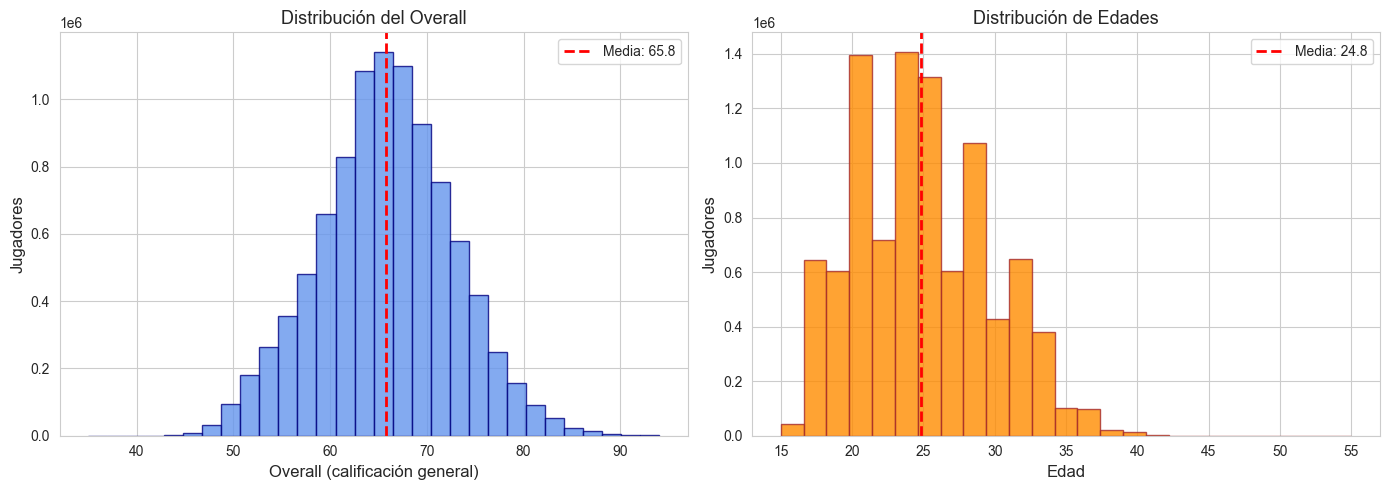

In [ ]:
  # === EDA INICIAL ===

  print('TOP 10 JUGADORES (por Overall)')
  print('=' * 70)
  top10 = df[['short_name', 'overall', 'potential', 'value_eur',
              'player_positions', 'club_name']].nlargest(10, 'overall')
  print(top10.to_string(index=False))

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  axes[0].hist(df['overall'].dropna(), bins=30, color='cornflowerblue',
              edgecolor='navy', alpha=0.8)
  axes[0].axvline(df['overall'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Media: {df['overall'].mean():.1f}")
  axes[0].set_xlabel('Overall (calificación general)', fontsize=12)
  axes[0].set_ylabel('Jugadores', fontsize=12)
  axes[0].set_title('Distribución del Overall', fontsize=13)
  axes[0].legend()

  axes[1].hist(df['age'].dropna(), bins=25, color='darkorange',
              edgecolor='brown', alpha=0.8)
  axes[1].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Media: {df['age'].mean():.1f}")
  axes[1].set_xlabel('Edad', fontsize=12)
  axes[1].set_ylabel('Jugadores', fontsize=12)
  axes[1].set_title('Distribución de Edades', fontsize=13)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

---
# Parte 2: Preparación de Datos

> **Conexión con Notebook 01** — Limpiamos el dataset, manejamos valores faltantes y
> creamos la variable `position_cat` (target de clasificación).

Las dos celdas siguientes ya están implementadas. **Léelas con atención.**


In [ ]:
# === [CÓDIGO COMPLETO] LIMPIEZA DE DATOS ===

print('Valores faltantes antes de limpiar:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# 1. Solo jugadores con valor de mercado conocido (> 0)
df = df[df['value_eur'] > 0].copy()

# 2. Solo jugadores con posición conocida
df = df[df['player_positions'].notna()].copy()

# 3. Eliminar filas con NaN en las 6 stats principales
STATS_PRINCIPALES = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
df = df.dropna(subset=STATS_PRINCIPALES).copy()

# 4. Rellenar NaN restantes con la mediana
cols_num = df.select_dtypes(include=[np.number]).columns
df[cols_num] = df[cols_num].fillna(df[cols_num].median())

print(f'\nDataset limpio: {df.shape[0]:,} jugadores')
print(f'Valores faltantes restantes: {df.isnull().sum().sum()}')

Valores faltantes antes de limpiar:
club_name     110573
value_eur     126119
wage_eur      110176
pace         1065123
shooting     1065123
passing      1065123
dribbling    1065123
defending    1065123
physic       1065123
dtype: int64

Dataset limpio: 8,328,994 jugadores
Valores faltantes restantes: 345


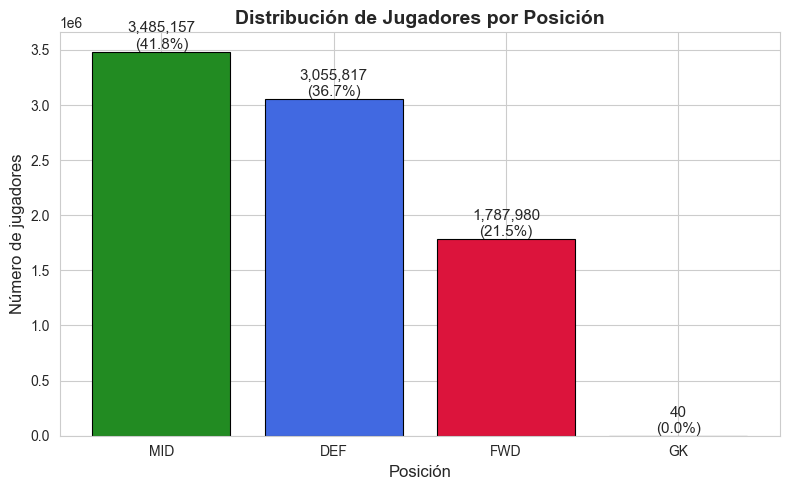


Dataset final: 8,328,994 jugadores con 4 categorías de posición


In [ ]:
# === [CÓDIGO COMPLETO] FEATURE ENGINEERING: CATEGORÍA DE POSICIÓN ===

MAPA_POSICIONES = {
    'GK': 'GK',
    'CB': 'DEF', 'LB': 'DEF', 'RB': 'DEF', 'LWB': 'DEF', 'RWB': 'DEF',
    'CM': 'MID', 'CAM': 'MID', 'CDM': 'MID', 'LM': 'MID', 'RM': 'MID',
    'ST': 'FWD', 'CF': 'FWD', 'LW': 'FWD', 'RW': 'FWD',
    'LS': 'FWD', 'RS': 'FWD', 'LF': 'FWD', 'RF': 'FWD',
}

def categorizar_posicion(pos_str):
    if pd.isna(pos_str):
        return None
    pos_principal = pos_str.split(',')[0].strip()
    return MAPA_POSICIONES.get(pos_principal, 'MID')

df['position_cat'] = df['player_positions'].apply(categorizar_posicion)
df = df[df['position_cat'].notna()].copy()

dist = df['position_cat'].value_counts()
colores_pos = {'GK': 'gold', 'DEF': 'royalblue', 'MID': 'forestgreen', 'FWD': 'crimson'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dist.index, dist.values,
              color=[colores_pos[p] for p in dist.index],
              edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Posición', fontsize=12)
ax.set_ylabel('Número de jugadores', fontsize=12)
ax.set_title('Distribución de Jugadores por Posición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nDataset final: {len(df):,} jugadores con {len(dist)} categorías de posición')

---
## EJERCICIO 1: EDA del Target + Preparación Final
**Dificultad:** ⭐⭐☆ (Media) — **15 puntos**

---

### Contexto

El valor de mercado (`value_eur`) tiene una distribución muy sesgada a la derecha:
unos pocos jugadores (Mbappé, Haaland...) tienen valores enormes mientras la gran
mayoría vale mucho menos. Esto dificulta el aprendizaje de los modelos.

**Solución:** transformación logarítmica → `y_log = np.log1p(value_eur)`

Para convertir predicciones de vuelta a euros: `np.expm1(y_pred_log)`

### Instrucciones

1. **TODO 1.1** — Grafica side-by-side la distribución de `value_eur`:
   - Izquierda: histograma de `value_eur` (escala normal)
   - Derecha: histograma de `np.log1p(value_eur)`
   - Añade títulos, etiquetas y línea de la media en cada gráfica

2. **TODO 1.2** — Define `FEATURES_NUMERICAS` (la lista de columnas features)

3. **TODO 1.3** — Crea los 4 splits (`X_train_r`, `X_test_r`, `X_train_c`, `X_test_c`)
   - Para regresión: target = `np.log1p(df['value_eur'])`
   - Para clasificación: target = `df['position_cat']`, usa `stratify=y_clf`
   - Ambos con `test_size=0.2`


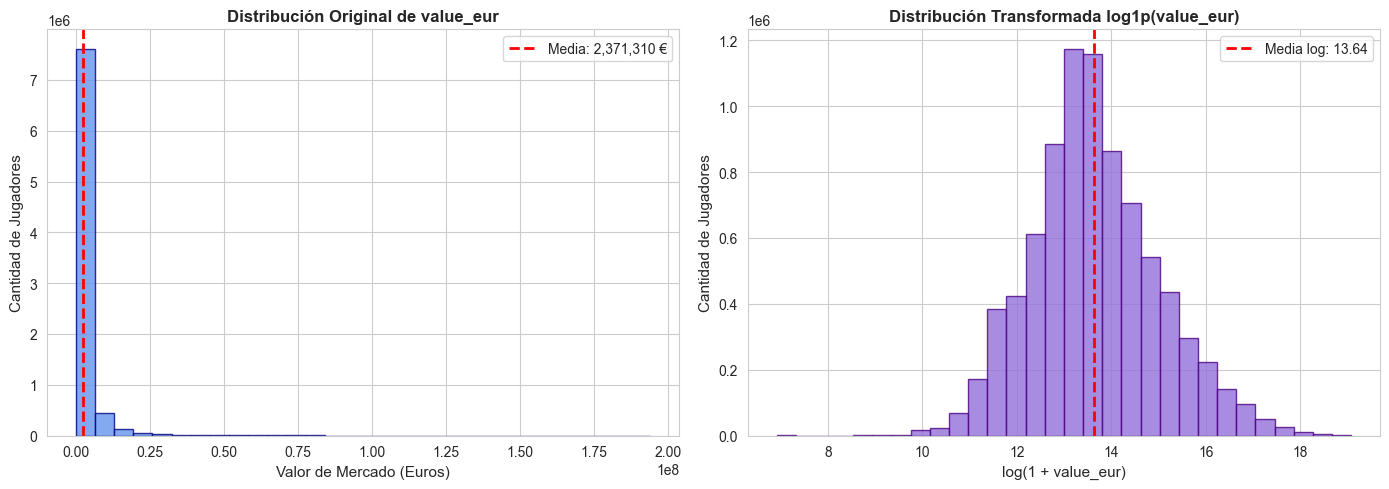

Features seleccionadas: ['age', 'overall', 'potential', 'height_cm', 'weight_kg', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'weak_foot', 'skill_moves', 'international_reputation']
VERIFICACIÓN EJERCICIO 1
  Features:          14 columnas
  Train regresión:   6,663,195 muestras
  Test  regresión:   1,665,799 muestras
  Train clasificación: 6,663,195 muestras
  Test  clasificación: 1,665,799 muestras

  Distribución posiciones (test):
position_cat
MID    0.418
DEF    0.367
FWD    0.215
GK     0.000
Name: proportion, dtype: float64


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 1: EDA del Target + Preparación Final         ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 1.1: Distribución de value_eur vs log1p(value_eur) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tu código aquí:
# Histograma Izquierdo: value_eur sin transformar
axes[0].hist(df['value_eur'].dropna(), bins=30, color='cornflowerblue', edgecolor='navy', alpha=0.8)
axes[0].axvline(df['value_eur'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Media: {df['value_eur'].mean():,.0f} €")
axes[0].set_xlabel('Valor de Mercado (Euros)', fontsize=11)
axes[0].set_ylabel('Cantidad de Jugadores', fontsize=11)
axes[0].set_title('Distribución Original de value_eur', fontsize=12, fontweight='bold')
axes[0].legend()

# Histograma Derecho: np.log1p(df['value_eur'])
y_log_preview = np.log1p(df['value_eur'])
axes[1].hist(y_log_preview, bins=30, color='mediumpurple', edgecolor='indigo', alpha=0.8)
axes[1].axvline(y_log_preview.mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Media log: {y_log_preview.mean():.2f}")
axes[1].set_xlabel('log(1 + value_eur)', fontsize=11)
axes[1].set_ylabel('Cantidad de Jugadores', fontsize=11)
axes[1].set_title('Distribución Transformada log1p(value_eur)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


# ── TODO 1.2: Features numéricas ─────────────────────────────────────────────
FEATURES_NUMERICAS = [
    'age', 'overall', 'potential', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'weak_foot', 'skill_moves', 'international_reputation'
]
print(f'Features seleccionadas: {FEATURES_NUMERICAS}')


# ── TODO 1.3: Splits train/test ───────────────────────────────────────────────

# — Regresión —
X_reg = df[FEATURES_NUMERICAS].copy()
y_reg = np.log1p(df['value_eur'])  # TODO: np.log1p(df['value_eur'])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)  # TODO: train_test_split(...)

# — Clasificación —
X_clf = df[FEATURES_NUMERICAS].copy()
y_clf = df['position_cat']  # TODO: df['position_cat']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)  # TODO: train_test_split(..., stratify=y_clf)


# ── VERIFICACIÓN ─────────────────────────────────────────────────────────────
print('=' * 55)
print('VERIFICACIÓN EJERCICIO 1')
print('=' * 55)
print(f'  Features:          {len(FEATURES_NUMERICAS)} columnas')
print(f'  Train regresión:   {X_train_r.shape[0]:,} muestras')
print(f'  Test  regresión:   {X_test_r.shape[0]:,} muestras')
print(f'  Train clasificación: {X_train_c.shape[0]:,} muestras')
print(f'  Test  clasificación: {X_test_c.shape[0]:,} muestras')
print(f'\n  Distribución posiciones (test):')
print(y_test_c.value_counts(normalize=True).round(3))

---
# Parte 3: Regresión — ¿Cuánto vale un jugador?

> **Conexión con Notebook 02** — Aplicamos modelos de regresión para predecir el valor de
> mercado. El target es `log1p(value_eur)` para manejar la distribución sesgada.
> Para interpretar las predicciones en euros reales: `np.expm1(y_pred)`.

La celda siguiente contiene las **funciones auxiliares** y el modelo de **Regresión Lineal**
como ejemplo completo. Estúdialos antes de implementar los ejercicios.



 Regresión Lineal
  RMSE: 0.3459
  MAE:  0.2580
  R2:   0.9347  (93.5% varianza explicada)


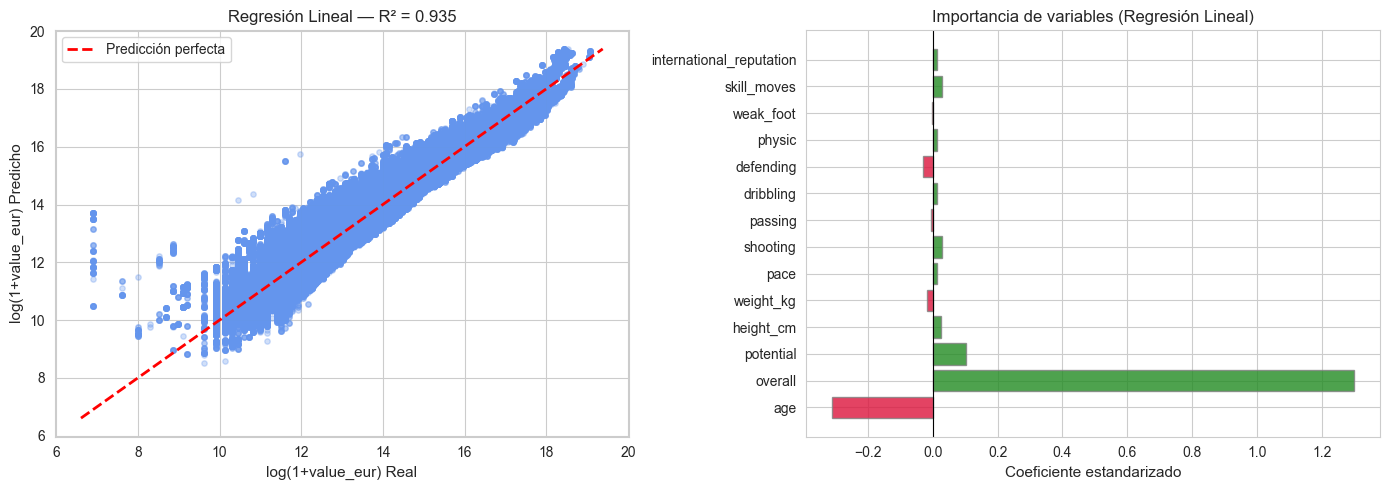

Verde = aumenta el valor | Rojo = disminuye el valor


In [ ]:
# === [CÓDIGO COMPLETO] FUNCIONES AUXILIARES + REGRESIÓN LINEAL ===

resultados_reg = []   # Acumula resultados para comparación final

def evaluar_regresion(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f"\n{'='*50}\n {nombre}\n{'='*50}")
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R2:   {r2:.4f}  ({r2*100:.1f}% varianza explicada)')
    resultados_reg.append({'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    return r2


# ── Regresión Lineal (modelo base) ───────────────────────────────────────────
pipe_lr_r = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])
pipe_lr_r.fit(X_train_r, y_train_r)
y_pred_lr_r = pipe_lr_r.predict(X_test_r)

r2_lr = evaluar_regresion(y_test_r, y_pred_lr_r, 'Regresión Lineal')

# Gráficas: Pred vs Real + Coeficientes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lim = [y_test_r.min() - 0.3, y_test_r.max() + 0.3]
axes[0].scatter(y_test_r, y_pred_lr_r, alpha=0.3, s=15, color='cornflowerblue')
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('log(1+value_eur) Real', fontsize=11)
axes[0].set_ylabel('log(1+value_eur) Predicho', fontsize=11)
axes[0].set_title(f'Regresión Lineal — R² = {r2_lr:.3f}', fontsize=12)
axes[0].legend()

coefs = pipe_lr_r.named_steps['modelo'].coef_
colores = ['forestgreen' if c > 0 else 'crimson' for c in coefs]
axes[1].barh(FEATURES_NUMERICAS, coefs, color=colores, edgecolor='gray', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coeficiente estandarizado', fontsize=11)
axes[1].set_title('Importancia de variables (Regresión Lineal)', fontsize=12)

plt.tight_layout()
plt.show()
print('Verde = aumenta el valor | Rojo = disminuye el valor')

---
## EJERCICIO 2: Árbol de Decisión para Regresión
**Dificultad:** ⭐⭐☆ (Media) — **15 puntos**

---

Los árboles de decisión dividen el espacio de features en regiones rectangulares y predicen
el **promedio** del target en cada región. Capturan relaciones **no lineales**, a diferencia
de la regresión lineal.

**Riesgo:** sin límites de profundidad el árbol memoriza el set de entrenamiento (overfitting).

### Instrucciones

1. **TODO 2.1** — Crea y entrena un `Pipeline([('scaler', StandardScaler()), ('modelo', DecisionTreeRegressor(...))])`
   - Usa `max_depth=6` y `min_samples_leaf=10` como punto de partida
2. **TODO 2.2** — Genera predicciones y llama a `evaluar_regresion()`
3. **TODO 2.3** — Grafica Predicciones vs Valores Reales (igual al ejemplo de arriba)
4. **TODO 2.4** *(Bonus)* — Grafica R² en test para `max_depth` de 1 a 15


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 2: Árbol de Decisión para Regresión           ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 2.1: Pipeline con DecisionTreeRegressor ─────────────────────────────
pipe_dt_r = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE))
])
pipe_dt_r.fit(X_train_r, y_train_r)


# ── TODO 2.2: Predicciones + evaluación ──────────────────────────────────────
y_pred_dt_r = pipe_dt_r.predict(X_test_r)

r2_dt = evaluar_regresion(y_test_r, y_pred_dt_r, 'Árbol de Decisión (Regresión)')


# ── TODO 2.3: Gráfica Predicciones vs Real ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

lim = [y_test_r.min() - 0.3, y_test_r.max() + 0.3]
ax.scatter(y_test_r, y_pred_dt_r, alpha=0.3, s=15, color='cornflowerblue')
ax.plot(lim, lim, 'r--', linewidth=2, label='Predicción perfecta')
ax.legend()

ax.set_xlabel('log(1+value_eur) Real', fontsize=11)
ax.set_ylabel('log(1+value_eur) Predicho', fontsize=11)
ax.set_title(f'Árbol de Decisión — R² = {r2_dt:.3f}', fontsize=12)
plt.tight_layout()
plt.show()


# ── TODO 2.4 (Bonus): R² vs max_depth ────────────────────────────────────────
profundidades = range(1, 16)
r2_train_list = []
r2_test_list  = []

for depth in profundidades:
    pipe_temp = Pipeline([('scaler', StandardScaler()),
                          ('modelo', DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE))])
    pipe_temp.fit(X_train_r, y_train_r)

    r2_train_list.append(r2_score(y_train_r, pipe_temp.predict(X_train_r)))
    r2_test_list.append(r2_score(y_test_r,   pipe_temp.predict(X_test_r)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(profundidades, r2_train_list, 'o-',  label='Train R²', color='steelblue')
ax.plot(profundidades, r2_test_list,  's--', label='Test R²',  color='tomato')
ax.axvline(x=6, color='gray', linestyle=':', linewidth=1.2, label='max_depth=6 (base)')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('R² en Train vs Test según max_depth', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'X_train_r' is not defined

---
## EJERCICIO 3: KNN para Regresión
**Dificultad:** ⭐⭐☆ (Media) — **15 puntos**

---

KNN predice el valor de un jugador promediando los valores de sus K "vecinos" más similares.
La estandarización es **obligatoria** (KNN calcula distancias; sin escalar, variables con
rango grande dominarían).

### Instrucciones

1. **TODO 3.1** — `Pipeline` con `StandardScaler` + `KNeighborsRegressor(n_neighbors=5)`
2. **TODO 3.2** — Predicciones y `evaluar_regresion()`
3. **TODO 3.3** — Grafica R² en test para K de 1 a 30 e identifica el mejor K

> **Recuerda:** K=1 → sobreajuste perfecto en train | K grande → subajuste


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 3: KNN para Regresión                         ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 3.1: Pipeline con KNeighborsRegressor ───────────────────────────────
pipe_knn_r = None  # Tu código aquí
# pipe_knn_r.fit(...)


# ── TODO 3.2: Predicciones + evaluación ──────────────────────────────────────
y_pred_knn_r = None  # Tu código aquí

r2_knn_r = evaluar_regresion(y_test_r, y_pred_knn_r, 'KNN Regresión (K=5)')


# ── TODO 3.3: Gráfica R² vs K ────────────────────────────────────────────────
k_valores  = range(1, 31)
r2_por_k   = []

for k in k_valores:
    pipe_temp = Pipeline([('scaler', StandardScaler()),
                          ('modelo', KNeighborsRegressor(n_neighbors=k))])
    # Tu código aquí: entrena, predice en test, calcula R²
    pass

fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(list(k_valores), r2_por_k, 's-', color='darkorange', linewidth=2)
ax.set_xlabel('Número de vecinos K', fontsize=12)
ax.set_ylabel('R² en test', fontsize=12)
ax.set_title('KNN Regresión: R² según K', fontsize=13)
plt.tight_layout()
plt.show()

mejor_k_r = None  # Tu código: k con mayor R²
print(f'Mejor K para regresión: {mejor_k_r}')


In [ ]:
# === [CÓDIGO COMPLETO] COMPARACIÓN DE MODELOS DE REGRESIÓN ===

df_reg = pd.DataFrame(resultados_reg).round(4)

print('=' * 60)
print('COMPARACIÓN — MODELOS DE REGRESIÓN (FIFA 23)')
print('Target: log(1 + value_eur)')
print('=' * 60)
print()
print(df_reg.to_string(index=False))

mejor = df_reg.loc[df_reg['R2'].idxmax()]
print(f'\nMejor modelo por R2: {mejor["Modelo"]} (R2 = {mejor["R2"]:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = ['cornflowerblue', 'forestgreen', 'darkorange'][:len(df_reg)]
for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(df_reg['Modelo'], df_reg[metrica], color=colores, edgecolor='black')
    for bar, val in zip(bars, df_reg[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Comparación de Modelos de Regresión — FIFA 23', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Parte 4: Clasificación — ¿Cuál es la posición del jugador?

> **Conexión con Notebook 03** — Predecimos la posición (GK/DEF/MID/FWD) a partir de los stats.
> Es clasificación **multiclase** (4 categorías). Las métricas clave son Accuracy, F1 y
> la Matriz de Confusión.

La celda siguiente implementa la **Regresión Logística** como ejemplo completo.


In [ ]:
# === [CÓDIGO COMPLETO] REGRESIÓN LOGÍSTICA PARA CLASIFICACIÓN ===

resultados_clf = []

def evaluar_clasificacion(y_real, y_pred, nombre):
    acc = accuracy_score(y_real, y_pred)
    print(f"\n{'='*55}\n {nombre}\n{'='*55}")
    print(f'  Accuracy: {acc:.4f}  ({acc*100:.1f}%)')
    print('\n  Reporte por clase:')
    print(classification_report(y_real, y_pred))
    resultados_clf.append({'Modelo': nombre, 'Accuracy': acc})
    return acc


pipe_lr_c = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipe_lr_c.fit(X_train_c, y_train_c)
y_pred_lr_c = pipe_lr_c.predict(X_test_c)

acc_lr_c = evaluar_clasificacion(y_test_c, y_pred_lr_c, 'Regresión Logística')

# Matriz de confusión
clases = ['GK', 'DEF', 'MID', 'FWD']
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_c, y_pred_lr_c, labels=clases)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=clases, yticklabels=clases, annot_kws={'size': 13})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — Reg. Logística\nAccuracy: {acc_lr_c:.3f}', fontsize=13)
plt.tight_layout()
plt.show()


---
## EJERCICIO 4: Árbol de Decisión + KNN para Clasificación
**Dificultad:** ⭐⭐⭐ (Alta) — **20 puntos**

---

### Parte A — Árbol de Decisión Clasificador

1. `Pipeline` con `StandardScaler` + `DecisionTreeClassifier`
2. Limita `max_depth` (entre 8 y 15) para evitar sobreajuste
3. Llama a `evaluar_clasificacion()` y grafica la matriz de confusión

### Parte B — KNN Clasificador

1. `Pipeline` con `StandardScaler` + `KNeighborsClassifier(n_neighbors=9)`
2. Llama a `evaluar_clasificacion()` y grafica la matriz de confusión

### Análisis (escribe tus conclusiones en la celda Markdown siguiente):
- ¿Cuál modelo supera a la Regresión Logística?
- ¿Qué posición es más difícil de clasificar? ¿Por qué?
- ¿Los porteros (GK) son fáciles de identificar?

> **Observación esperada:** Los GK se distinguen fácilmente. La confusión suele ser
> entre MID y FWD, que tienen stats similares.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 4: Árbol de Decisión + KNN Clasificación      ║
# ╚══════════════════════════════════════════════════════════╝

clases = ['GK', 'DEF', 'MID', 'FWD']

# ════════════════════════════════════════════════
# PARTE A: ÁRBOL DE DECISIÓN
# ════════════════════════════════════════════════

# ── TODO 4A.1: Pipeline DecisionTreeClassifier ───────────────────────────────
pipe_dt_c = None  # Tu código aquí
# pipe_dt_c.fit(...)

y_pred_dt_c = None  # Tu código aquí
acc_dt_c = evaluar_clasificacion(y_test_c, y_pred_dt_c, 'Árbol de Decisión (Clasificación)')

# ── TODO 4A.2: Matriz de confusión ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
# cm = confusion_matrix(y_test_c, y_pred_dt_c, labels=clases)
# sns.heatmap(...)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════
# PARTE B: KNN CLASIFICADOR
# ════════════════════════════════════════════════

# ── TODO 4B.1: Pipeline KNeighborsClassifier ─────────────────────────────────
pipe_knn_c = None  # Tu código aquí
# pipe_knn_c.fit(...)

y_pred_knn_c = None  # Tu código aquí
acc_knn_c = evaluar_clasificacion(y_test_c, y_pred_knn_c, 'KNN Clasificación (K=9)')

# ── TODO 4B.2: Matriz de confusión ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
# Tu código aquí
plt.tight_layout()
plt.show()


### Análisis del Ejercicio 4 — Escribe tus conclusiones aquí

**Edita esta celda y responde:**

1. ¿Cuál modelo obtuvo mayor accuracy? ¿Cuánto supera a la Regresión Logística?

2. ¿Qué posición fue la más difícil de clasificar? Apoya tu respuesta con los números de la matriz.

3. ¿Los porteros (GK) fueron fáciles de identificar? ¿Qué stats crees que los distinguen?

4. ¿Hubo confusión entre algún par de posiciones? ¿Tiene sentido futbolísticamente?

*Tu respuesta aquí...*


---
## EJERCICIO 5: Random Forest para Clasificación + Importancia de Variables
**Dificultad:** ⭐⭐⭐ (Alta) — **20 puntos**

---

### Instrucciones

1. **TODO 5.1** — `Pipeline` con `RandomForestClassifier(n_estimators=200, random_state=42)`
2. **TODO 5.2** — Predice, llama a `evaluar_clasificacion()` y grafica la matriz de confusión
3. **TODO 5.3** — Extrae `feature_importances_` y grafica las 14 variables ordenadas
4. **TODO 5.4** — Responde: ¿coinciden las variables más importantes con las de la regresión?

> **Acceso a importancias:** `pipe_rf_c.named_steps['modelo'].feature_importances_`

> **Esperas encontrar:** `defending` importante para GK/DEF; `shooting` y `pace` para FWD.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 5: Random Forest Clasificación               ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 5.1: Pipeline RandomForestClassifier ────────────────────────────────
pipe_rf_c = None  # Tu código aquí
# pipe_rf_c.fit(...)


# ── TODO 5.2: Predicciones, evaluación y matriz de confusión ─────────────────
y_pred_rf_c = None  # Tu código aquí
acc_rf_c = evaluar_clasificacion(y_test_c, y_pred_rf_c, 'Random Forest (Clasificación)')

fig, ax = plt.subplots(figsize=(7, 6))
# Tu código aquí: matriz de confusión
plt.tight_layout()
plt.show()


# ── TODO 5.3: Importancia de variables ───────────────────────────────────────
importancias_c = None  # pipe_rf_c.named_steps['modelo'].feature_importances_

df_imp_c = pd.DataFrame({
    'Variable': FEATURES_NUMERICAS,
    'Importancia': importancias_c
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
# Tu código aquí: barh con las importancias
ax.set_xlabel('Importancia relativa', fontsize=12)
ax.set_title('Importancia de Variables — RF Clasificación (Posición)', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 5 variables para predecir la posición:')
# Tu código aquí


---
# Parte 6: Validación y Ajuste del Mejor Modelo

> **Conexión con Notebook 05** — Usamos validación cruzada para evaluar el modelo de forma
> más robusta, y luego `GridSearchCV` para encontrar los hiperparámetros óptimos.

La celda siguiente muestra la validación cruzada del Random Forest (regresión) como ejemplo.


In [ ]:
# === [CÓDIGO COMPLETO] VALIDACIÓN CRUZADA ===

print('=' * 60)
print('VALIDACIÓN CRUZADA 5-FOLD — Random Forest (Regresión)')
print('=' * 60)
print()
print('Un único train/test split depende de la suerte del sorteo.')
print('La validación cruzada evalúa el modelo en 5 particiones distintas.')

cv_scores = cross_val_score(pipe_rf_r, X_reg, y_reg, cv=5, scoring='r2', n_jobs=-1)

print(f'\nScores por fold: {cv_scores.round(4)}')
print(f'Media:           {cv_scores.mean():.4f}')
print(f'Desv. estándar:  {cv_scores.std():.4f}')
print(f'Resultado final: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='forestgreen', edgecolor='black', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Media: {cv_scores.mean():.4f}')
ax.fill_between(range(0, 7),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='red', label='±1 desv. std.')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Validación Cruzada 5-Fold — Random Forest Regresión', fontsize=13)
ax.set_xlim(0.5, 5.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


---
## EJERCICIO 6: GridSearchCV — Ajuste del Mejor Modelo de Clasificación
**Dificultad:** ⭐⭐⭐ (Alta) — **15 puntos**

---

### Instrucciones

1. **TODO 6.1** — Define la grilla con al menos 3 hiperparámetros

```python
param_grid = {
    'modelo__n_estimators': [50, 100, 200],
    'modelo__max_depth':    [10, 20, None],
    'modelo__min_samples_leaf': [1, 2, 5]
}
```

> ⚠️ En un `Pipeline`, los parámetros del estimador se prefijan con el nombre del paso:
> `'modelo__n_estimators'` (no solo `'n_estimators'`).

2. **TODO 6.2** — Ejecuta `GridSearchCV` con `cv=StratifiedKFold(5)` y `scoring='accuracy'`

3. **TODO 6.3** — Compara el accuracy antes y después del ajuste (validación cruzada)

4. **TODO 6.4** *(Bonus)* — Prueba `RandomizedSearchCV` con `n_iter=20` y compara tiempos

> ⏱️ **Tiempo estimado:** 3–10 min. Empieza con la grilla pequeña sugerida.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 6: GridSearchCV                               ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 6.1: Grilla de hiperparámetros ──────────────────────────────────────
param_grid = {
    # Tu código aquí (al menos 3 parámetros)
    # 'modelo__n_estimators': [...],
    # 'modelo__max_depth': [...],
    # 'modelo__min_samples_leaf': [...]
}

n_combos = 1
for vals in param_grid.values():
    n_combos *= len(vals)
print(f'Combinaciones: {n_combos} × 5 folds = {n_combos * 5} entrenamientos')


# ── TODO 6.2: GridSearchCV ────────────────────────────────────────────────────
pipe_base_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

grid_search = None  # Tu código aquí: GridSearchCV(...)

print('Buscando mejores hiperparámetros...')
# grid_search.fit(X_train_c, y_train_c)


# ── TODO 6.3: Resultados y comparación ───────────────────────────────────────
print('\n' + '=' * 60)
print('RESULTADOS GRID SEARCH')
print('=' * 60)

# Tu código: imprime grid_search.best_params_ y grid_search.best_score_

acc_antes = cross_val_score(pipe_rf_c, X_clf, y_clf, cv=5,
                             scoring='accuracy', n_jobs=-1).mean()
acc_despues = None  # Tu código: CV del mejor estimador

print(f'\nAccuracy CV antes del ajuste:   {acc_antes:.4f}')
print(f'Accuracy CV después del ajuste: {acc_despues:.4f}')
print(f'Mejora: {(acc_despues - acc_antes)*100:+.2f} pp')


In [ ]:
# === TABLA RESUMEN FINAL ===

print('=' * 65)
print('RESUMEN FINAL DEL PROYECTO — FIFA 23 Players')
print('=' * 65)

if resultados_reg:
    print('\n--- REGRESIÓN (Target: log(1+value_eur)) ---')
    df_reg_f = pd.DataFrame(resultados_reg).round(4)
    print(df_reg_f.to_string(index=False))
    mejor_r = df_reg_f.loc[df_reg_f['R2'].idxmax()]
    print(f'  Mejor: {mejor_r["Modelo"]} — R² = {mejor_r["R2"]:.4f}')

if resultados_clf:
    print('\n--- CLASIFICACIÓN (Target: position_cat GK/DEF/MID/FWD) ---')
    df_clf_f = pd.DataFrame(resultados_clf).round(4)
    print(df_clf_f.to_string(index=False))
    mejor_c = df_clf_f.loc[df_clf_f['Accuracy'].idxmax()]
    print(f'  Mejor: {mejor_c["Modelo"]} — Accuracy = {mejor_c["Accuracy"]:.4f}')


---
# Criterios de Evaluación y Entrega

## Rúbrica (100 puntos)

| Ejercicio | Descripción | Puntos |
|-----------|-------------|--------|
| **Ejercicio 1** | EDA del target + splits correctos con stratify | 15 pts |
| **Ejercicio 2** | Árbol de Decisión regresión + gráfica Pred vs Real | 15 pts |
| **Ejercicio 3** | KNN regresión + gráfica R² vs K | 15 pts |
| **Ejercicio 4** | Árbol + KNN clasificación + análisis escrito | 20 pts |
| **Ejercicio 5** | Random Forest clasificación + gráfica importancia | 20 pts |
| **Ejercicio 6** | GridSearchCV + comparación antes/después | 15 pts |
| **Total** | | **100 pts** |

### Criterios transversales (aplican a todos los ejercicios):
- El código corre **sin errores** *(requisito mínimo para recibir puntos)*
- Las gráficas tienen **título, etiquetas de ejes** y son legibles
- Las métricas están **correctamente calculadas** y llamadas con `evaluar_*()`
- Las **conclusiones escritas** demuestran comprensión del resultado

## Bonus (hasta +10 puntos)

| Actividad | Puntos |
|-----------|--------|
| Implementar `GradientBoostingClassifier` y comparar con RF | +3 pts |
| Identificar jugadores mal clasificados y analizar por qué | +3 pts |
| Encontrar el mejor K del Ejercicio 3 con validación cruzada (no solo test) | +2 pts |
| Convertir las predicciones de regresión a euros reales con `np.expm1()` | +2 pts |

## Instrucciones de entrega

1. Ejecuta **todas las celdas** (Kernel → Restart & Run All) y verifica que no haya errores
2. Guarda el notebook como: `Proyecto_FIFA_[TuNombre]_[TuCódigo].ipynb`
3. Sube el archivo al enlace de entrega del curso

---
*Proyecto Integrador — Inteligencia Artificial y Aprendizaje Automático*
